# Analyze genome-wide mutation rates

Import Python modules

In [9]:
import os
import glob
import pandas as pd
import numpy as np
import glob
from collections import defaultdict
import math
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.0, style='ticks', palette='colorblind')
import scipy

if not os.path.isdir('../results/figures/'):
    os.makedirs('../results/figures/')

Read in data.

In [10]:
genome_wide_rates = pd.read_csv('../results/genome_wide_rates.csv')

Plot synonymous mutation rates.

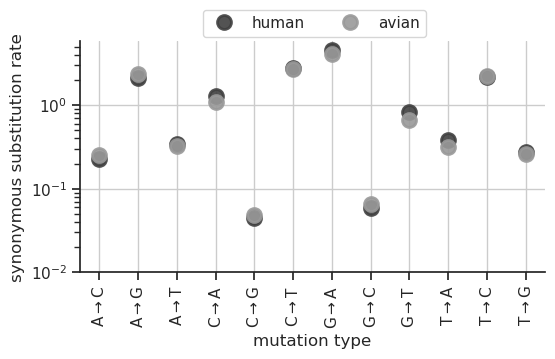

In [31]:
host_colors = {
    'human' : '0.25',
    'avian' : '0.6',
}
mut_type_order = genome_wide_rates['mut_type_arrow'].unique()
plt.figure(figsize=[6,3])
data = genome_wide_rates[genome_wide_rates['mut_class'] == 'synonymous']
sns.pointplot(
    x='mut_type_arrow', y='syn_rate', data=data,
    hue='host', order=mut_type_order, hue_order=['human', 'avian'],
    palette=host_colors,
    linestyle="none", marker="o", markersize=10, alpha=0.9
)
plt.xlabel('mutation type')
plt.xticks(rotation=90)
plt.ylabel('synonymous substitution rate')
plt.yscale('log')
plt.yticks([1e-2, 1e-1, 1e0])
plt.legend(bbox_to_anchor=(0.76,1.17), ncol=2)
plt.grid() # axis='y'
sns.despine()
plt.savefig('../results/figures/genome_wide_synonymous_rates.png', dpi=300, bbox_inches='tight')
plt.show()

Compare genome-wide rates of nonsynonymous and nonsense mutations relative to synonymous mutations.

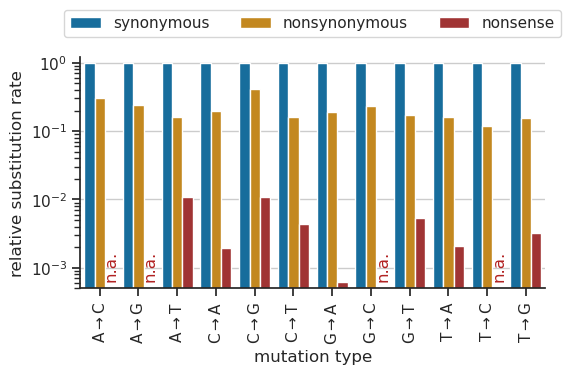

In [4]:
mut_class_colors = {
    'synonymous' : '#0173b2',
    'nonsynonymous' : '#de8f05',
    'nonsense' : 'firebrick',
}
mut_type_order = genome_wide_rates['mut_type_arrow'].unique()

# Plot the data
data = genome_wide_rates[genome_wide_rates['host'] == 'all']
plt.figure(figsize=[6,3])
sns.barplot(
    x='mut_type_arrow', y='rel_rate', data=data,
    order=mut_type_order, palette=mut_class_colors,
    hue='mut_class', hue_order = ['synonymous', 'nonsynonymous', 'nonsense']
)

# Add the text n.a. for mutation types that never lead to nonsense mutations
for (i, mut_type) in enumerate(data['mut_type'].unique()):
    if mut_type in ['AC', 'AG', 'GC', 'TC']:
        plt.annotate(
            'n.a.', ((i*1)+0.11, 0.0007),
            color=mut_class_colors['nonsense'], rotation=90
        )

plt.xlabel('mutation type')
plt.xticks(rotation=90)
plt.ylabel('relative substitution rate')
plt.yscale('log')
plt.yticks([1e-3, 1e-2, 1e-1, 1e0])
plt.ylim(0.0005, 1.2)
plt.legend(bbox_to_anchor=(1.05,1.24), ncol=3)
plt.grid(axis='y')
sns.despine()
plt.savefig('../results/figures/genome_wide_mut_class_rates.png', dpi=300, bbox_inches='tight')
plt.show()

Compare genome-wide synonymous mutation rates between influenza, SARS2, and HIV.

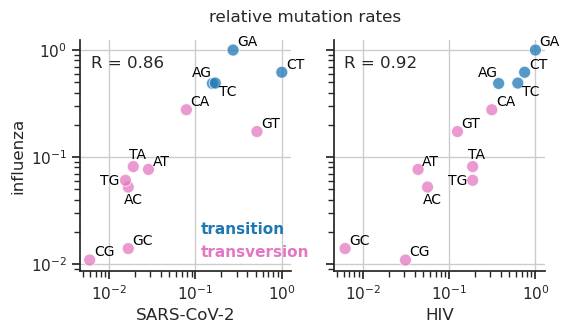

In [5]:
# Get SARS2 data
s2_data = pd.read_csv('../../../2024/SARS2-synonymous-mut-rate/results/median_syn_mut_rates.csv')

# Get HIV data
hiv_mut_rates = {
    'GC' : 1e-7,
    'AT' : 7e-7,
    'CG' : 5e-7,
    'AC' : 9e-7,
    'GT' : 2e-6,
    'TA' : 3e-6,
    'TG' : 3e-6,
    'CA' : 5e-6,
    'AG' : 6e-6,
    'TC' : 1e-5,
    'CT' : 1.2e-5,
    'GA' : 1.6e-5
}
hiv_data = pd.DataFrame.from_dict(hiv_mut_rates, orient='index', columns=['HIV']).reset_index().rename(columns={'index':'mut_type'})

# Merge with flu data from human hosts
transitions = ['AG', 'GA', 'CT', 'TC']
data = (
    genome_wide_rates[
        (genome_wide_rates['mut_class'] == 'synonymous') &
        (genome_wide_rates['host'] == 'all')
    ][['mut_type', 'rate']]
    .rename(columns={'rate':'influenza'})
    .merge(s2_data)
    .merge(hiv_data)
    .rename(columns={'actual_count':'SARS-CoV-2'})
    .assign(category = lambda x: x['mut_type'].apply(lambda y: 'transition' if y in transitions else 'transversion'))
)
for col in ['influenza', 'SARS-CoV-2', 'HIV']:
    data[col] = data[col] / data[col].max()

# Define colors for mutation categories
category_colors = {
    'transition': '#1f77b4',      # Dark blue-gray
    'transversion': '#e377c2'     # Pink/Magenta
}

# Plot the comparisons
(fig, axs) = plt.subplots(ncols=2, figsize=[6,3], sharey=True, sharex=True)

for i, virus in enumerate(['SARS-CoV-2', 'HIV']):
    sns.scatterplot(
        x=virus, y='influenza', data=data, s=75, alpha=0.75,
        hue='category', hue_order=['transition', 'transversion'],
        palette=category_colors,
        ax=axs[i]
    )

    r, p = scipy.stats.pearsonr(np.log(data[virus]), np.log(data['influenza']))
    axs[i].annotate(text=f'R = {r:.2f}', xy=(0.05, 0.88), xycoords='axes fraction', fontsize=12)

    # Annotate each point with its label from the DataFrame
    offset_dict = {
        'AC' : (-3,-12),
        'AG' : (-15,5),
        'TA' : (-3,6),
        'TC' : (3,-9),
        'TG' : (-18,-3),
    }
    for row_i, row in data.iterrows():
        mut_type = row['mut_type']
        if mut_type in offset_dict:
            offset = offset_dict[mut_type]
        else:
            offset = (3, 3)
        axs[i].annotate(
            text=mut_type,
            xy=(row[virus], row['influenza']),
            xytext=offset,
            textcoords='offset points',
            fontsize=10,
            color='black'
        )
    # plt.legend(bbox_to_anchor=(1,1))
    plt.suptitle('relative mutation rates', fontsize=12)
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].grid()

# Get the legend and customize it
legend = axs[0].legend(loc='lower right', bbox_to_anchor=(1.15, -0.01))
for handle in legend.legend_handles:
    handle.set_markersize(0)  # Remove markers
for text, handle in zip(legend.get_texts(), legend.legend_handles):
    text.set_color(handle.get_color())  # Color text
    text.set_weight('bold')  # Make text bold
legend.set_frame_on(False)

axs[1].get_legend().remove()
sns.despine()
plt.savefig('../results/figures/genome_wide_rates_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

For each virus, quantify the degree of symmetry between complement mutation types.

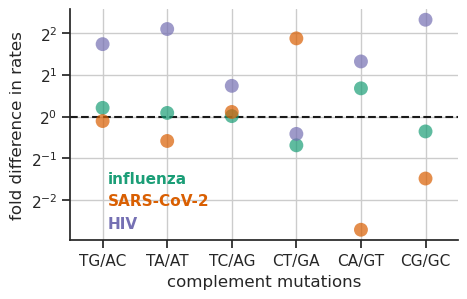

In [6]:
# Compute fold differences in rate between complement mutation types
mut_type_pairs = [
    ['TG', 'AC'],
    ['TA', 'AT'],
    ['TC', 'AG'],
    ['CT', 'GA'],
    ['CA', 'GT'],
    ['CG', 'GC'],
]
pair_data = data.set_index('mut_type')[['influenza', 'SARS-CoV-2', 'HIV']].T
pairs = []
for mut_type_pair in mut_type_pairs:
    pair = f'{mut_type_pair[0]}/{mut_type_pair[1]}'
    pairs.append(pair)
    pair_data[pair] = pair_data[mut_type_pair[0]] / pair_data[mut_type_pair[1]]

pair_data = pd.melt(
    pair_data[pairs].T.reset_index(),
    id_vars='mut_type', value_name='fold difference in rates', var_name='virus'
)

# Plot fold differences
plt.figure(figsize=[5,3])
sns.stripplot(
    x='mut_type', y='fold difference in rates', data=pair_data, hue='virus',
    jitter=False, size=10, alpha=0.7, palette='Dark2'
)
plt.axhline(1, ls='--', c='k')
plt.xlabel('complement mutations')
plt.yscale('log', base=2)

# Get the legend and customize it
legend = plt.legend(loc='lower left', bbox_to_anchor=(-0.05, -0.02))
for handle in legend.legend_handles:
    handle.set_markersize(0)  # Remove markers
for text, handle in zip(legend.get_texts(), legend.legend_handles):
    text.set_color(handle.get_color())  # Color text
    text.set_weight('bold')  # Make text bold
legend.set_frame_on(False)

plt.grid()
sns.despine()
plt.savefig('../results/figures/genome_wide_fold_differences.png', dpi=300, bbox_inches='tight')
plt.show()